In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import gpplot as gpp
gpp.set_aesthetics(context = 'paper')
from scipy.stats import fisher_exact

In [2]:
#read in cleaned crispri nonessentials
noness_labeled = pd.read_csv('../../Data/offTargetAnalysis/CleanedOffTargetTiling.csv')
noness_labeled

/var/folders/mj/lhpd16ys0cx2wkbhm7s0nfcm0000gp/T/ipykernel_65931/2653538518.py:2: DtypeWarning: Columns (4) have mixed types. Specify dtype option on import or set low_memory=False.
  noness_labeled = pd.read_csv('../../Data/offTargetAnalysis/CleanedOffTargetTiling.csv')


,Target Gene Symbol,Category,TSS Position,sgRNA Sequence,sgRNA Context Sequence,On-Target Efficacy Score,sgRNA 'Cut' Site TSS Offset,avg_lfc_A549_Zim3,z_scored_avg_lfc_A549_Zim3,avg_lfc_A549_Kox1,z_scored_avg_lfc_A549_Kox1,avg_lfc_HCT116_Zim3,z_scored_avg_lfc_HCT116_Zim3,avg_lfc_HCT116_Kox1,z_scored_avg_lfc_HCT116_Kox1,avg_zscore,gene_avg_zscore,Unnamed: 17,label,promiscuous
0,OR6K6,Non-essential,158754721.0,AAAAAAAAAAGGTCATTCAG,CTAGAAAAAAAAAAGGTCATTCAGGGGTCC,-0.1532,-24.0,0.216872,0.023685,-0.110835,-0.744721,-0.265074,-1.285187,-0.272546,-1.421982,-0.857051,0.137831,nonpromiscuous,nonpromiscuous,False
1,CYP7A1,Non-essential,58500163.0,AAAAAAAAAGTGGTAGTAAC,TAGAAAAAAAAAAGTGGTAGTAACTGGCCT,-0.2355,-121.0,-0.292964,-1.334599,-0.183103,-0.920208,-0.069267,-0.811182,0.119249,-0.389626,-0.863904,0.003741,nonpromiscuous,nonpromiscuous,False
2,IL22,Non-essential,68253604.0,AAAAAAAAGTCAGTATCCTG,AATTAAAAAAAAGTCAGTATCCTGGGGGCT,-0.1535,-39.0,0.410484,0.539497,0.152376,-0.105570,-0.168406,-1.051176,0.264744,-0.006253,-0.155875,0.051320,nonpromiscuous,nonpromiscuous,False
3,DEFB126,Non-essential,142591.0,AAAAAAACAAAAGTGAAATG,AGCAAAAAAAACAAAAGTGAAATGAGGCAG,0.1482,410.0,0.231700,0.063188,-0.041797,-0.577077,-0.334828,-1.454046,-0.050205,-0.836125,-0.701015,0.173317,nonpromiscuous,nonpromiscuous,False
4,IL22,Non-essential,68253604.0,AAAAAAAGTCAGTATCCTGG,ATTAAAAAAAAGTCAGTATCCTGGGGGCTA,0.3508,-38.0,0.350938,0.380855,0.009976,-0.451357,0.336373,0.170781,0.782455,1.357887,0.364541,0.051320,nonpromiscuous,nonpromiscuous,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
33226,ONE_INTERGENIC_874,ONE_INTERGENICO_CTL,NaN,TTTGATCTGTAGCAGATGAC,NaN,NaN,NaN,0.323391,0.307466,0.545505,0.849061,0.104767,-0.389885,0.512509,0.646595,0.353309,NaN,nonpromiscuous,nonpromiscuous,False
33227,ONE_INTERGENIC_70,ONE_INTERGENICO_CTL,NaN,TTTGGAATTATCATCGTCGT,NaN,NaN,NaN,0.214765,0.018071,0.267283,0.173456,0.450597,0.447290,0.472803,0.541969,0.295197,NaN,nonpromiscuous,nonpromiscuous,False
33228,ONE_INTERGENIC_108,ONE_INTERGENICO_CTL,NaN,TTTGGAGTGATATTCGAACA,NaN,NaN,NaN,0.353744,0.388331,-0.581978,-1.888791,0.423880,0.382615,-0.002250,-0.709769,-0.456903,NaN,nonpromiscuous,nonpromiscuous,False
33229,ONE_INTERGENIC_33,ONE_INTERGENICO_CTL,NaN,TTTGGCAGTCTATTACGGTA,NaN,NaN,NaN,0.103618,-0.278042,0.155628,-0.097672,-0.150519,-1.007875,0.194114,-0.192360,-0.393987,NaN,nonpromiscuous,nonpromiscuous,False


### Assess effect of GG presence at any position along context sequence on promiscuity

In [3]:
pos_cols = []
for i in range(0,29):
    pos_cols.append(i)
    noness_labeled[i] = noness_labeled['sgRNA Context Sequence'].str[i:(i+2)] == 'GG'

In [4]:
noness_labeled

,Target Gene Symbol,Category,TSS Position,sgRNA Sequence,sgRNA Context Sequence,On-Target Efficacy Score,sgRNA 'Cut' Site TSS Offset,avg_lfc_A549_Zim3,z_scored_avg_lfc_A549_Zim3,avg_lfc_A549_Kox1,...,19,20,21,22,23,24,25,26,27,28
0,OR6K6,Non-essential,158754721.0,AAAAAAAAAAGGTCATTCAG,CTAGAAAAAAAAAAGGTCATTCAGGGGTCC,-0.1532,-24.0,0.216872,0.023685,-0.110835,...,False,False,False,False,True,True,True,False,False,False
1,CYP7A1,Non-essential,58500163.0,AAAAAAAAAGTGGTAGTAAC,TAGAAAAAAAAAAGTGGTAGTAACTGGCCT,-0.2355,-121.0,-0.292964,-1.334599,-0.183103,...,False,False,False,False,False,False,True,False,False,False
2,IL22,Non-essential,68253604.0,AAAAAAAAGTCAGTATCCTG,AATTAAAAAAAAGTCAGTATCCTGGGGGCT,-0.1535,-39.0,0.410484,0.539497,0.152376,...,False,False,False,False,True,True,True,True,False,False
3,DEFB126,Non-essential,142591.0,AAAAAAACAAAAGTGAAATG,AGCAAAAAAAACAAAAGTGAAATGAGGCAG,0.1482,410.0,0.231700,0.063188,-0.041797,...,False,False,False,False,False,False,True,False,False,False
4,IL22,Non-essential,68253604.0,AAAAAAAGTCAGTATCCTGG,ATTAAAAAAAAGTCAGTATCCTGGGGGCTA,0.3508,-38.0,0.350938,0.380855,0.009976,...,False,False,False,True,True,True,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
33226,ONE_INTERGENIC_874,ONE_INTERGENICO_CTL,NaN,TTTGATCTGTAGCAGATGAC,NaN,NaN,NaN,0.323391,0.307466,0.545505,...,False,False,False,False,False,False,False,False,False,False
33227,ONE_INTERGENIC_70,ONE_INTERGENICO_CTL,NaN,TTTGGAATTATCATCGTCGT,NaN,NaN,NaN,0.214765,0.018071,0.267283,...,False,False,False,False,False,False,False,False,False,False
33228,ONE_INTERGENIC_108,ONE_INTERGENICO_CTL,NaN,TTTGGAGTGATATTCGAACA,NaN,NaN,NaN,0.353744,0.388331,-0.581978,...,False,False,False,False,False,False,False,False,False,False
33229,ONE_INTERGENIC_33,ONE_INTERGENICO_CTL,NaN,TTTGGCAGTCTATTACGGTA,NaN,NaN,NaN,0.103618,-0.278042,0.155628,...,False,False,False,False,False,False,False,False,False,False


In [5]:
#drop rows without context sequences (intergenics) for this particular analysis
noness_labeled_with_context_sequence = noness_labeled[~noness_labeled['sgRNA Context Sequence'].isna()].copy()

plot_df = noness_labeled_with_context_sequence.melt(id_vars = ['sgRNA Sequence','promiscuous'],
                                                    var_name = 'Position',
                                                    value_vars = pos_cols,
                                                    value_name = 'is_GG')
plot_df = plot_df.groupby(['Position','is_GG']).agg(prop_promiscuous = ('promiscuous','mean'),
                                                    group_size = ('sgRNA Sequence','count')).reset_index()
plot_df

,Position,is_GG,prop_promiscuous,group_size
0,0,False,0.043923,29165
1,0,True,0.061415,3110
2,1,False,0.044150,28992
3,1,True,0.058483,3283
4,2,False,0.044228,29099
5,2,True,0.058249,3176
6,3,False,0.042771,29155
7,3,True,0.072115,3120
8,4,False,0.042184,29158
9,4,True,0.077639,3117


In [6]:
#check what minimum denominator is
plot_df['group_size'].min()

2358

In [9]:
#create new column for labels for positions on plot (which are unchanged for positions along the guide sequence)
plot_df['Position Label'] = plot_df['Position']
plot_df.loc[plot_df['Position'] < 4,'Position Label'] -= 4
plot_df.loc[(plot_df['Position'] >= 4) & (plot_df['Position'] <= 23),'Position Label'] -= 3
plot_df.loc[plot_df['Position'] > 26,'Position Label'] -= 26
plot_df.loc[plot_df['Position'] > 26,'Position Label'] = '+' + plot_df.loc[plot_df['Position'] > 26,'Position Label'].astype(str)
plot_df['Position Label'] = plot_df['Position Label'].astype(str)
plot_df.loc[plot_df['Position'] == 24,'Position Label'] = 'N'
#need separate identifiers for the Gs in the PAM because otherwise they will be grouped into one bar on the plot
plot_df.loc[(plot_df['Position'] == 25),'Position Label'] = 'G1'
plot_df.loc[(plot_df['Position'] == 26),'Position Label'] = 'G2'
plot_df = plot_df.sort_values(by='Position')
plot_df['is_GG'] = np.where(plot_df['is_GG'],'GG','other dinucleotide')
plot_df

,Position,is_GG,prop_promiscuous,group_size,Position Label
0,0,other dinucleotide,0.043923,29165,-4
1,0,GG,0.061415,3110,-4
2,1,other dinucleotide,0.044150,28992,-3
3,1,GG,0.058483,3283,-3
4,2,other dinucleotide,0.044228,29099,-2
5,2,GG,0.058249,3176,-2
6,3,other dinucleotide,0.042771,29155,-1
7,3,GG,0.072115,3120,-1
8,4,other dinucleotide,0.042184,29158,1
9,4,GG,0.077639,3117,1


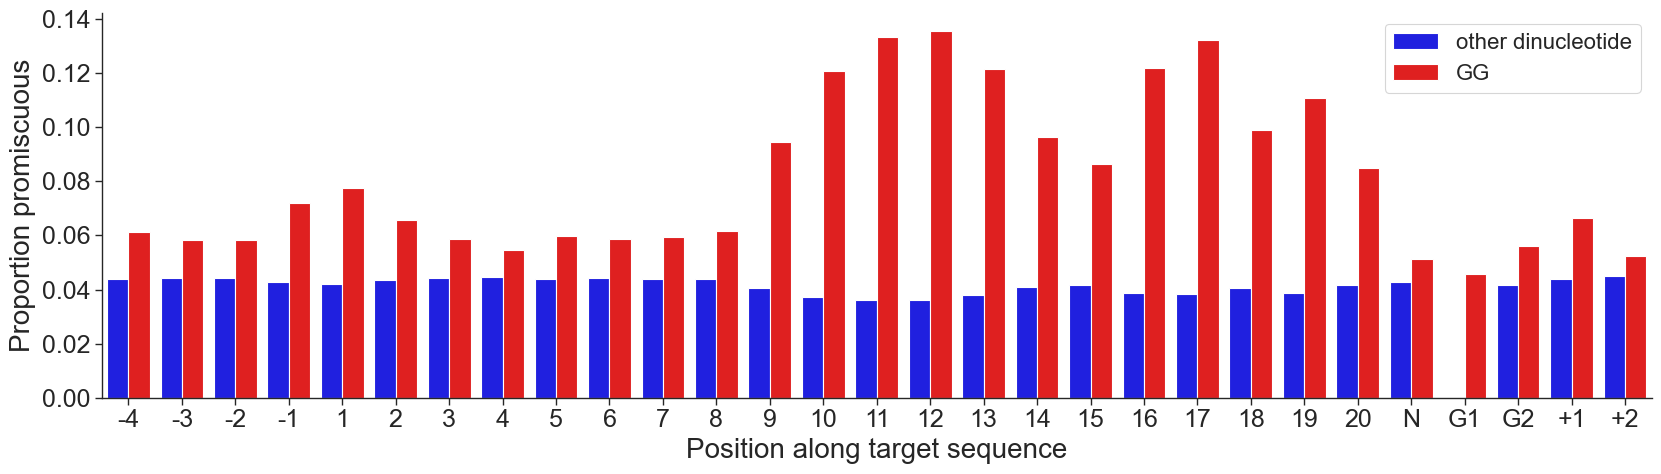

In [15]:
plt.figure(figsize = (20,5))
sns.barplot(data = plot_df, x = 'Position Label', y = 'prop_promiscuous', hue = 'is_GG', palette = {'GG':'red','other dinucleotide':'blue'})
plt.legend(title='is GG',fontsize=14, title_fontsize=18)
plt.xlabel('Position along target sequence',fontsize=20)
plt.ylabel('Proportion promiscuous',fontsize=20)
#plt.xlim(-20,20)
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
sns.despine()
plt.legend(title='',fontsize=16)

gpp.savefig("../../Figures/Figure 5/gg_position_vs_promiscuity_barplot.pdf",dpi=300, bbox_inches = 'tight')
gpp.savefig("../../Figures/Figure 5/gg_position_vs_promiscuity_barplot.png",dpi=600, bbox_inches = 'tight')

GGs within the 12 bases most proximal to the PAM appear to influence promiscuity substantially more than other positions. Therefore, it makes sense to consider a 12bp seed sequence for subsequent analyses.

### How does count of every nucleotide within the 12bp correlate with promiscuity?

In [18]:
def count_overlapping_matches(seq,pattern):
    count = 0
    length = len(pattern)
    for i in range(len(seq)-1):
        if seq[i:(i+length)] == pattern:
            count +=1
    return count

In [19]:
n_list = ['A','T','C','G']
din_list = []
for n1 in n_list:
    for n2 in n_list:
        din_list.append(n1+n2)

In [20]:
#create separate column with seed sequence
noness_labeled.loc[:,'seed_seq'] = noness_labeled['sgRNA Sequence'].str[-12:]
#create column for every nucleotide containing number of occurrences within the seed sequence
for din in din_list:
    noness_labeled.loc[:,din] = noness_labeled.loc[:,'seed_seq'].apply(lambda seq: count_overlapping_matches(seq,din))

In [21]:
#calculate proportion of guides that are promiscuous for each dinucleotide/count group
plot_df = noness_labeled.melt(id_vars = ['sgRNA Sequence','promiscuous'],
                              var_name = 'Dinucleotide',
                              value_vars = din_list,
                              value_name = 'num_occurrences')
#bin dinucleotide occurrences to aggregate counts >=3 into one category (for plotting)
bins = [0,1,2,3,4,np.inf]
labels = ['0','1','2','3','>3']
plot_df['num_occurrence_bin'] = pd.cut(plot_df['num_occurrences'], bins = bins, labels = labels, right = False)

#calculate proportion of guides with each count of each dinucleotide that are promiscuous
plot_df = plot_df.groupby(['Dinucleotide',
                           'num_occurrence_bin']).agg(prop_promiscuous = ('promiscuous','mean'),
                                                      sum_promiscuous = ('promiscuous','sum'),
                                                      group_size = ('sgRNA Sequence','count')).reset_index()


#only consider combinations with at least 30 guides
plot_df = plot_df[plot_df['group_size'] >= 30].copy()

#pivot df to allow to be plotted as heatmap
plot_df = plot_df.pivot(columns = ['Dinucleotide'], index = 'num_occurrence_bin',
              values = 'prop_promiscuous')
plot_df = plot_df.sort_values(by = ['>3'], axis=1, ascending=False)
plot_df

Dinucleotide,GG,AG,GA,CC,CG,GC,GT,CA,AA,CT,AC,TC,TG,TT,AT,TA
num_occurrence_bin,,,,,,,,,,,,,,,,
0,0.011451,0.023314,0.027760,0.049119,0.040903,0.041390,0.054719,0.060818,0.053138,0.064695,0.060453,0.063067,0.055343,0.059711,0.066232,0.060602
1,0.018441,0.035075,0.037926,0.028931,0.050999,0.044908,0.034409,0.038828,0.040286,0.033359,0.028001,0.024386,0.042011,0.015334,0.017002,0.014049
2,0.066881,0.066139,0.075807,0.037666,0.070629,0.051635,0.022329,0.027312,0.026382,0.018538,0.018142,0.020583,0.028999,0.005574,0.002187,0.002016
3,0.173628,0.143675,0.153589,0.050669,0.064257,0.053463,0.014252,0.018573,0.014543,0.018182,0.018476,0.015773,0.016563,0.000000,0.000000,0.000000
>3,0.293874,0.225352,0.202703,0.112689,0.064516,0.021277,0.020833,0.018519,0.010753,0.010638,0.000000,0.000000,0.000000,0.000000,NaN,NaN


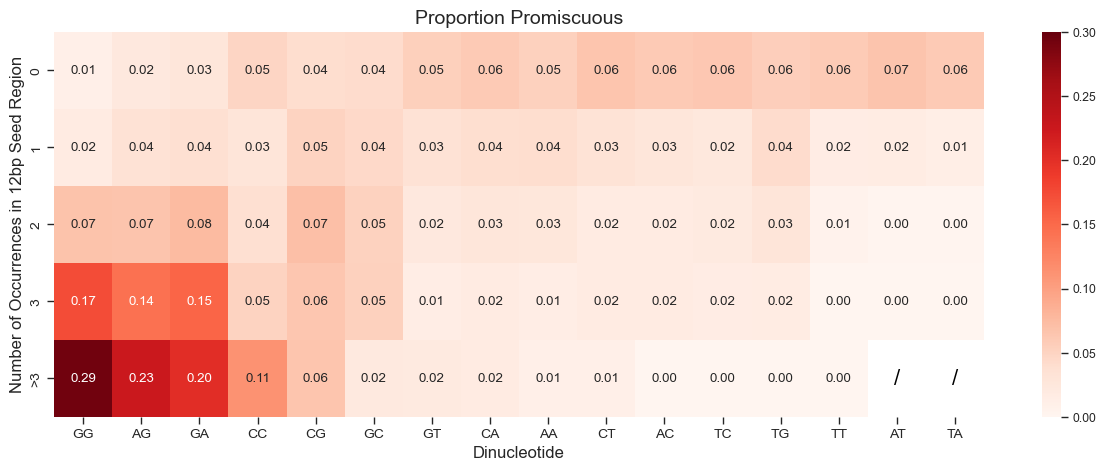

In [23]:
plt.figure(figsize=(15,5))
ax = sns.heatmap(plot_df,cmap='Reds',
               vmin=0, vmax=0.3, annot=True, fmt = '0.2f')
for i in range(plot_df.shape[0]):
    for j in range(plot_df.shape[1]):
        if np.isnan(plot_df.iloc[i, j]):
            ax.text(j + 0.5, i + 0.5, "/", ha='center', va='center', color='black', fontsize=16)
plt.xlabel('Dinucleotide',fontsize=12)
plt.ylabel('Number of Occurrences in 12bp Seed Region',fontsize=12)
plt.title('Proportion Promiscuous', fontsize=14)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

gpp.savefig("../../Figures/Figure 5/12bp_seed_dinucleotide_counts_vs_promiscuity_heatmap.pdf",dpi=300, bbox_inches = 'tight')
gpp.savefig("../../Figures/Figure 5/12bp_seed_dinucleotide_counts_vs_promiscuity_heatmap.png",dpi=600, bbox_inches = 'tight')

### Are these differences in proportion truly statistically significant? What cutoff would capture the largest fraction of promiscuous guides?

In [24]:
#calculate proportion of guides that are promiscuous for each dinucleotide/count group
plot_df = noness_labeled.melt(id_vars = ['sgRNA Sequence','promiscuous'],
                              var_name = 'Dinucleotide',
                              value_vars = din_list,
                              value_name = 'num_occurrences')

#if we considered all guides with >=0 counts of a certain dinucleotide, we would simply be considering every guide in the dataset
plot_df = plot_df[plot_df['num_occurrences'] > 0].copy()

#bin dinucleotide occurrences to aggregate counts >=3 into one category (for plotting)
bins = [1,2,3,4,np.inf]
labels = ['>=1','>=2','>=3','>3']
plot_df['num_occurrence_bin'] = pd.cut(plot_df['num_occurrences'], bins = bins, labels = labels, right = False)

#calculate proportion of guides with each count of each dinucleotide that are promiscuous
plot_df = plot_df.groupby(['Dinucleotide',
                           'num_occurrence_bin']).agg(prop_promiscuous = ('promiscuous','mean'),
                                                      sum_promiscuous = ('promiscuous','sum'),
                                                      group_size = ('sgRNA Sequence','count')).reset_index()

#calculate number of guides / promiscuous guides with AT LEAST a certain count of each dinucleotide
plot_df['cumsum_promiscuous'] = plot_df[::-1].groupby('Dinucleotide')['sum_promiscuous'].transform('cumsum')
plot_df['cum_group_size'] = plot_df[::-1].groupby('Dinucleotide')['group_size'].transform('cumsum')

#recalculate proportion of promiscuous guides
plot_df['cumprop_promiscuous'] = plot_df['cumsum_promiscuous']/plot_df['cum_group_size']


#only consider groups with at least 30 guides for consistency with previous plot
plot_df = plot_df[plot_df['cum_group_size'] >= 30].copy()


#implement Fisher Exact test

total_promiscuous = noness_labeled['promiscuous'].sum()
total_nonpromiscuous = (~noness_labeled['promiscuous']).sum()
plot_df.loc[:,'p_value'] = plot_df.apply(lambda row: fisher_exact(np.array([[row['cumsum_promiscuous'],row['cum_group_size']-row['cumsum_promiscuous']],
                                                                  [total_promiscuous,total_nonpromiscuous]]),
                                         alternative = 'greater').pvalue, axis=1)
plot_df.loc[:,'-log(p-value)'] = -np.log10(plot_df.loc[:,'p_value'])

plot_df

,Dinucleotide,num_occurrence_bin,prop_promiscuous,sum_promiscuous,group_size,cumsum_promiscuous,cum_group_size,cumprop_promiscuous,p_value,-log(p-value)
0,AA,>=1,0.040286,333,8266,456,14017,0.032532,1.0,1.983830e-10
1,AA,>=2,0.026382,94,3563,123,5751,0.021388,1.0,-0.000000e+00
2,AA,>=3,0.014543,21,1444,29,2188,0.013254,1.0,4.821637e-17
3,AA,>3,0.010753,8,744,8,744,0.010753,1.0,1.578114e-08
4,AC,>=1,0.028001,324,11571,390,15250,0.025574,1.0,-0.000000e+00
...,...,...,...,...,...,...,...,...,...,...
59,TG,>3,0.000000,0,86,0,86,0.000000,1.0,-0.000000e+00
60,TT,>=1,0.015334,117,7630,132,10706,0.012330,1.0,-0.000000e+00
61,TT,>=2,0.005574,15,2691,15,3076,0.004876,1.0,-0.000000e+00
62,TT,>=3,0.000000,0,342,0,385,0.000000,1.0,-0.000000e+00


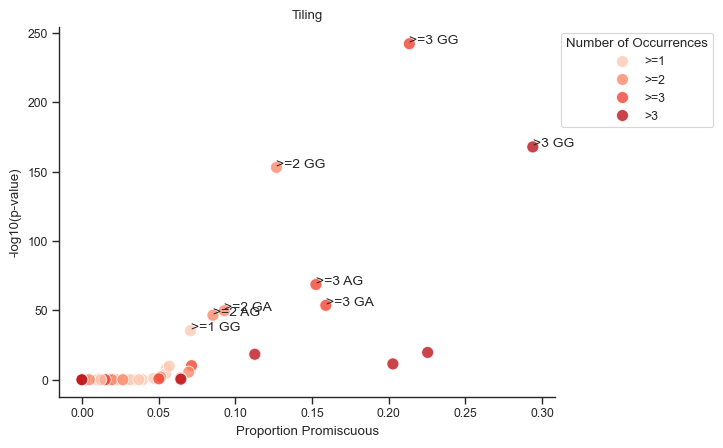

In [26]:
sns.scatterplot(data = plot_df, x = 'cumprop_promiscuous', y = '-log(p-value)', hue = 'num_occurrence_bin',
                palette='Reds', alpha = 0.8, s = 75)

texts = []
for i,row in plot_df.iterrows():
    x = row['cumprop_promiscuous']
    y = row['-log(p-value)']
    din = str(row['Dinucleotide'])
    n = str(row['num_occurrence_bin'])
    if (y > 20):
        text = plt.text(x, y, n + ' ' + din, fontsize=10)
sns.despine()

plt.xlabel('Proportion Promiscuous')
plt.ylabel('-log10(p-value)')
plt.legend(title = 'Number of Occurrences', bbox_to_anchor=(1,1))
plt.title('Tiling')

gpp.savefig("../../Figures/Figure 5/12bp_seed_dinucleotide_count_cutoffs_vs_promiscuity_volcano.pdf",dpi=300, bbox_inches = 'tight')
gpp.savefig("../../Figures/Figure 5/12bp_seed_dinucleotide_count_cutoffs_vs_promiscuity_volcano.png",dpi=600, bbox_inches = 'tight')

In [17]:
#if guides with >= 3 GGs were excluded from library design, what fraction of promiscuous guides would be captured?
(noness_labeled[noness_labeled['promiscuous']]['GG'] >= 3).mean()

0.5274204468517265

In [18]:
#what fraction of nonpromiscuous guides are unintentionally excluded?
(noness_labeled[~noness_labeled['promiscuous']]['GG'] >= 3).mean()

0.0904138061346602

In [19]:
plot_df[plot_df['num_occurrence_bin'] == '>3']

,Dinucleotide,num_occurrence_bin,prop_promiscuous,sum_promiscuous,group_size,cumsum_promiscuous,cum_group_size,cumprop_promiscuous,p_value,-log(p-value)
3,AA,>3,0.010753,8,744,8,744,0.010753,1.000000e+00,1.578114e-08
7,AC,>3,0.000000,0,49,0,49,0.000000,1.000000e+00,-0.000000e+00
11,AG,>3,0.225352,48,213,48,213,0.225352,2.084646e-20,1.968097e+01
19,CA,>3,0.018519,2,108,2,108,0.018519,9.554842e-01,1.977649e-02
23,CC,>3,0.112689,119,1056,119,1056,0.112689,4.299147e-19,1.836662e+01
27,CG,>3,0.064516,2,31,2,31,0.064516,4.037233e-01,3.939162e-01
31,CT,>3,0.010638,1,94,1,94,0.010638,9.860235e-01,6.112729e-03
35,GA,>3,0.202703,30,148,30,148,0.202703,3.891873e-12,1.140984e+01
39,GC,>3,0.021277,2,94,2,94,0.021277,9.250513e-01,3.383417e-02
43,GG,>3,0.293874,355,1208,355,1208,0.293874,1.129308e-168,1.679472e+02
